<div style="background:linear-gradient(135deg,#1a3a5c,#2980b9);border-radius:12px;padding:30px;text-align:center;margin-bottom:20px;">
  <h1 style="color:white;margin:0;font-size:32px;letter-spacing:1px;">Omar Gamal ElKady</h1>
  <p style="color:#cce4ff;margin:8px 0 4px;font-size:16px;">ITI Intake 46 &mdash; Track AI</p>
  <hr style="border:1px solid rgba(255,255,255,0.3);width:50%;margin:14px auto;">
  <h2 style="color:white;margin:0;font-size:24px;font-weight:400;">Lab 3: Facebook Prophet &mdash; Forecasting the Daily Delhi Climate Dataset</h2>
</div>

<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:10px;padding:20px;margin-bottom:15px;">
  <h3 style="color:#2e6da4;margin:0 0 12px;text-align:center;">Lab Roadmap</h3>
  <table border="0" cellpadding="10" cellspacing="0" style="border-collapse:collapse;width:100%;font-size:14px;color:#000;">
    <thead>
      <tr style="background:#2e6da4;color:white;">
        <th style="border-radius:6px 0 0 0;padding:10px;">#</th>
        <th>Section</th><th>Focus</th><th style="border-radius:0 6px 0 0;">Goal</th>
      </tr>
    </thead>
    <tbody>
      <tr style="background:#eaf4ff;"><td style="text-align:center;font-weight:bold;">1</td><td>Data Preparation</td><td style="text-align:center;">Tasks 1&ndash;3</td><td>Load the Delhi climate series, import Prophet, and map the schema to Prophet's required format.</td></tr>
      <tr style="background:#f8faff;"><td style="text-align:center;font-weight:bold;">2</td><td>Baseline Forecast</td><td style="text-align:center;">Tasks 4&ndash;5</td><td>Fit a default Prophet model and visualize the forecast with its decomposed components.</td></tr>
      <tr style="background:#eaf4ff;"><td style="text-align:center;font-weight:bold;">3</td><td>Model Tuning</td><td style="text-align:center;">Tasks 6&ndash;8</td><td>Explore changepoint flexibility, custom seasonality, and external regressors to improve accuracy.</td></tr>
      <tr style="background:#f8faff;"><td style="text-align:center;font-weight:bold;">4</td><td>Diagnostics</td><td style="text-align:center;">Tasks 9&ndash;11</td><td>Visualize changepoints, run time-series cross-validation, and compute rolling performance metrics.</td></tr>
      <tr style="background:#eaf4ff;"><td style="text-align:center;font-weight:bold;">5</td><td>Model Comparison</td><td style="text-align:center;">Task 12</td><td>Compare in-sample RMSE across all model trials against a naive mean baseline.</td></tr>
      <tr style="background:#f8faff;"><td style="text-align:center;font-weight:bold;">6</td><td>Final Forecast &amp; Serialization</td><td style="text-align:center;">Tasks 13&ndash;14</td><td>Evaluate the best model on the held-out test set and persist it with Prophet's JSON serialization.</td></tr>
      <tr style="background:#eaf4ff;"><td style="text-align:center;font-weight:bold;">7</td><td>Further Analysis</td><td style="text-align:center;">FA 1&ndash;5</td><td>Cross-validate m4, tune hyperparameters, analyse residuals, and quantify regressor importance.</td></tr>
    </tbody>
  </table>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 1: Import Necessary Libraries</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Import Prophet alongside the standard data science stack and Prophet's diagnostic utilities.</p>
</div>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# TODO 1: Import the following from prophet:
# - Prophet (from prophet)
# - plot_forecast_component (from prophet.plot)
# - cross_validation, performance_metrics (from prophet.diagnostics)

# Your imports here:
from prophet import Prophet
from prophet.plot import plot_forecast_component
from prophet.diagnostics import cross_validation, performance_metrics


<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 2: Load and Inspect the Dataset</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">Daily Delhi Climate</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">We use the <strong>sumanthvrao/daily-climate-time-series-data</strong> dataset. The target column is <code>meantemp</code>.</p>
</div>

In [2]:
# import kagglehub

# path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data", output_dir="dataset/")
# print("Path to dataset files:", path)

In [3]:
# TODO 2.1: Load 'DailyDelhiClimateTrain.csv' into a DataFrame.
df = pd.read_csv("dataset/DailyDelhiClimateTrain.csv")

# TODO 2.2: Print shape, dtypes, and first 5 rows.
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nFirst 5 rows:")
display(df.head())

# TODO 2.3: Check for missing values in meantemp and report the count.
print("\nMissing values in meantemp:", df["meantemp"].isna().sum())


Shape: (1462, 5)

Dtypes:
 date             object
meantemp        float64
humidity        float64
wind_speed      float64
meanpressure    float64
dtype: object

First 5 rows:


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000



Missing values in meantemp: 0


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 2 &mdash; Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>The dataset contains <strong>1,462 daily observations</strong> spanning 4 years (2013&ndash;2016) with 5 columns: <code>date</code>, <code>meantemp</code>, <code>humidity</code>, <code>wind_speed</code>, and <code>meanpressure</code>.</li>
    <li><strong>No missing values</strong> in <code>meantemp</code>.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 3: Schema Mapping</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">Prepare the Prophet-Compatible DataFrame</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Prophet requires exactly two columns: <code>ds</code> (datestamp) and <code>y</code> (target). Rename and cast accordingly.</p>
</div>

          ds          y   humidity  wind_speed  meanpressure
0 2013-01-01  10.000000  84.500000    0.000000   1015.666667
1 2013-01-02   7.400000  92.000000    2.980000   1017.800000
2 2013-01-03   7.166667  87.000000    4.633333   1018.666667
3 2013-01-04   8.666667  71.333333    1.233333   1017.166667
4 2013-01-05   6.000000  86.833333    3.700000   1016.500000


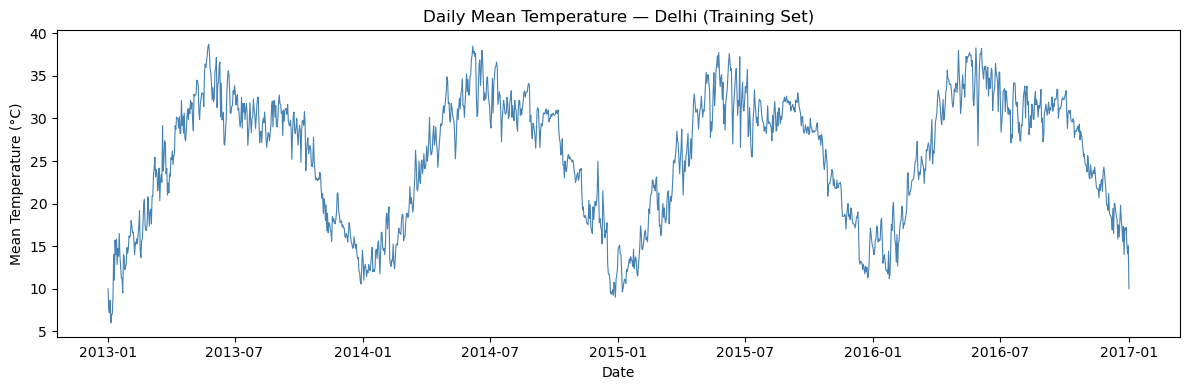

In [4]:
# TODO 3.1: Rename 'date' -> 'ds' and 'meantemp' -> 'y'.
prophet_df = df.rename(columns={"date": "ds", "meantemp": "y"})

# TODO 3.2: Convert 'ds' to datetime using pd.to_datetime().
prophet_df["ds"] = pd.to_datetime(prophet_df["ds"])

# TODO 3.3: Sort by 'ds' and reset the index.
prophet_df = prophet_df.sort_values("ds").reset_index(drop=True)

print(prophet_df.head())

# TODO 3.4: Plot the raw y series using matplotlib to inspect trend and seasonality.
# Use fig, ax = plt.subplots(figsize=(12, 4)).
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(prophet_df["ds"], prophet_df["y"], color="steelblue", linewidth=0.8)
ax.set_title("Daily Mean Temperature — Delhi (Training Set)")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Temperature (°C)")
plt.tight_layout()
plt.show()


<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 4: Model Trial 1 &mdash; Baseline Prophet</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">Default Settings</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Fit Prophet with all default parameters. This is your baseline before any tuning.</p>
</div>

In [5]:
# TODO 4.1: Instantiate Prophet() with default parameters and fit on prophet_df.
m1 = Prophet()
m1.fit(prophet_df)

# TODO 4.2: Create a future DataFrame for 365 days using make_future_dataframe().
future1 = m1.make_future_dataframe(periods=365)

# TODO 4.3: Generate forecast using model.predict().
forecast1 = m1.predict(future1)

# TODO 4.4: Display the last 5 rows of ['ds', 'yhat', 'yhat_lower', 'yhat_upper'].
print("\nNumber of columns:", len(forecast1.columns))
print("Column in forecast1:", forecast1.columns.tolist())
forecast1[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail()

14:26:53 - cmdstanpy - INFO - Chain [1] start processing
14:26:53 - cmdstanpy - INFO - Chain [1] done processing



Number of columns: 19
Column in forecast1: ['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper', 'additive_terms', 'additive_terms_lower', 'additive_terms_upper', 'weekly', 'weekly_lower', 'weekly_upper', 'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat']


,ds,yhat,yhat_lower,yhat_upper
1822,2017-12-28,15.763757,13.127597,18.386687
1823,2017-12-29,15.666927,13.094305,18.304471
1824,2017-12-30,15.534868,12.702829,18.145943
1825,2017-12-31,15.394141,12.708816,17.895157
1826,2018-01-01,15.582815,12.737485,18.213195


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 4 &mdash; Baseline Prophet Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>Default Prophet automatically detected both <strong>weekly</strong> and <strong>yearly</strong> seasonalities without any configuration.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 5: Visualizing the Baseline Forecast</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Use Prophet's built-in matplotlib plot functions to inspect the forecast and its decomposed components.</p>
</div>

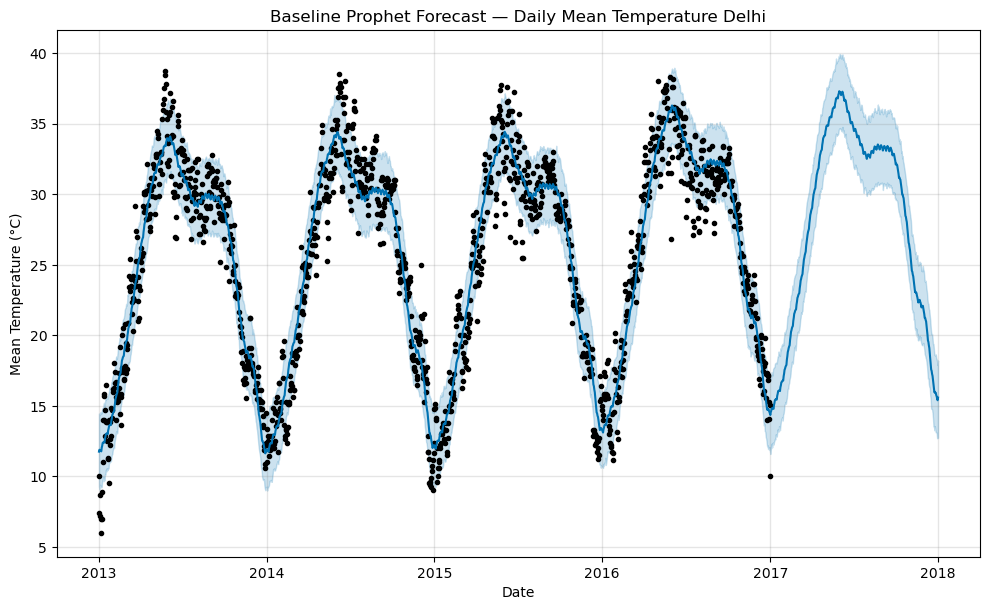

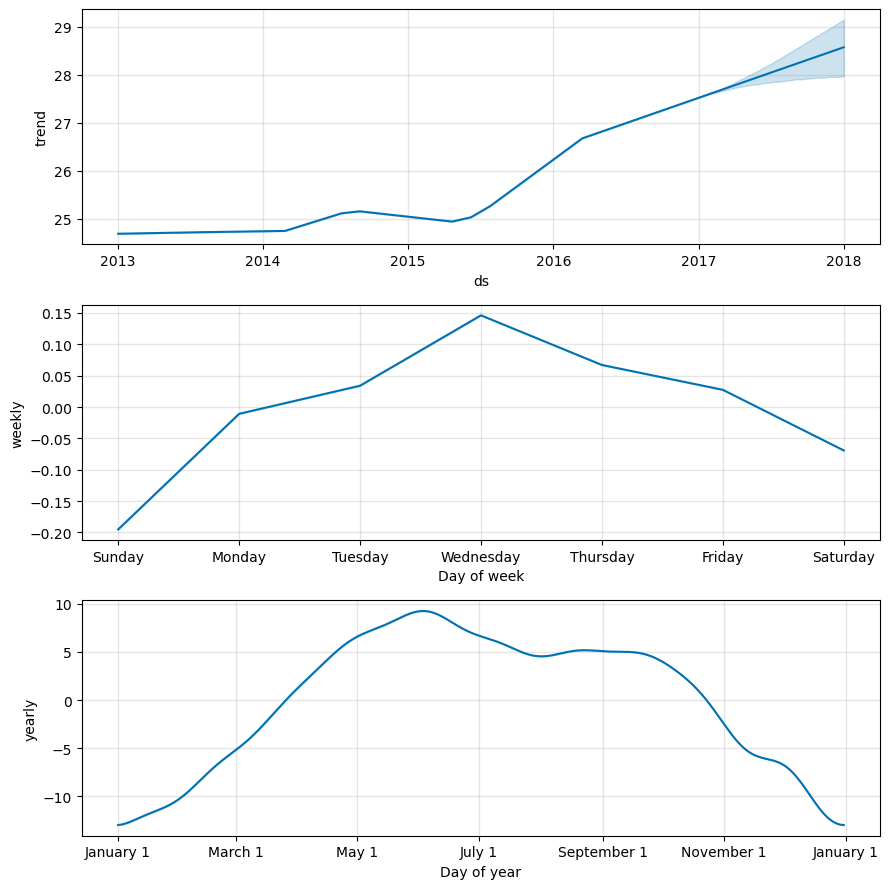

In [6]:
# TODO 5.1: Plot the full forecast using m1.plot(forecast1).
# Add a title and axis labels via the returned axes object.
fig1 = m1.plot(forecast1)
ax1 = fig1.gca()
ax1.set_title("Baseline Prophet Forecast — Daily Mean Temperature Delhi")
ax1.set_xlabel("Date")
ax1.set_ylabel("Mean Temperature (°C)")

# TODO 5.2: Plot the decomposed components using m1.plot_components(forecast1).
# Observe: trend, weekly seasonality, yearly seasonality.
fig2 = m1.plot_components(forecast1)

plt.tight_layout()
plt.show()


<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 6: Model Trial 2 &mdash; Tuning Growth and Changepoints</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Explore how <code>changepoint_prior_scale</code> affects trend flexibility by comparing three values: 0.001, 0.1, and 0.5.</p>
</div>

14:26:53 - cmdstanpy - INFO - Chain [1] start processing
14:26:53 - cmdstanpy - INFO - Chain [1] done processing
14:26:53 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
14:26:53 - cmdstanpy - INFO - Chain [1] start processing
14:26:54 - cmdstanpy - INFO - Chain [1] done processing
14:26:55 - cmdstanpy - INFO - Chain [1] start processing
14:26:55 - cmdstanpy - INFO - Chain [1] done processing
14:26:55 - cmdstanpy - INFO - Chain [1] start processing
14:26:55 - cmdstanpy - INFO - Chain [1] done processing


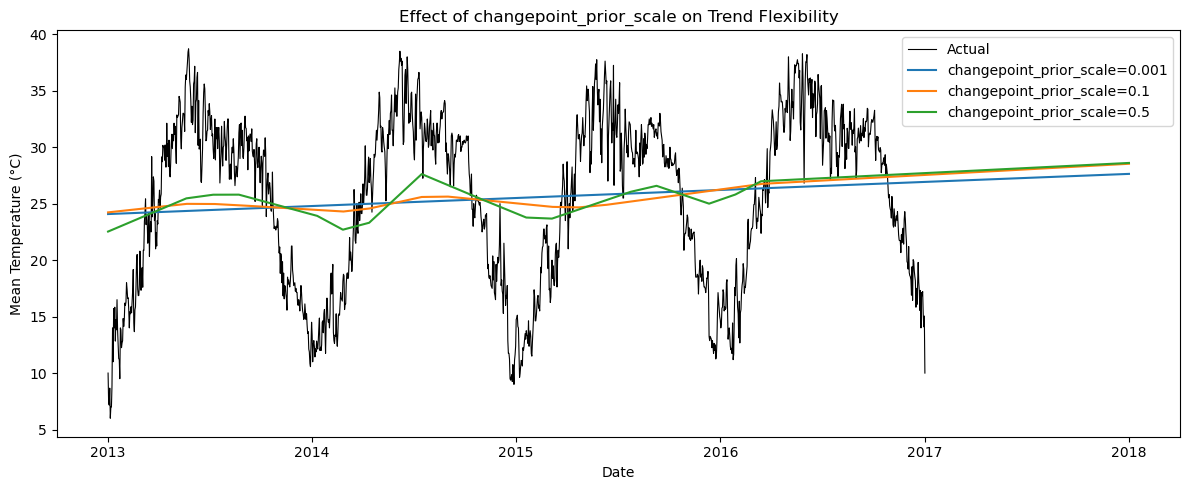

In [7]:
# TODO 6.1: Fit three Prophet models with changepoint_prior_scale = [0.001, 0.1, 0.5].
# Store trend forecasts in a dict: {scale_value: forecast_df}.
cps_results = {}

for cps in [0.001, 0.1, 0.5]:
    m = Prophet(changepoint_prior_scale=cps)
    m.fit(prophet_df)
    future = m.make_future_dataframe(periods=365)
    cps_results[cps] = m.predict(future)

# TODO 6.2: Plot all three trend lines on a single matplotlib figure (figsize=(12, 5)).
# Overlay the actual y series in black for reference.
# Label each trend line with its changepoint_prior_scale value in the legend.
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(prophet_df["ds"], prophet_df["y"], color="black", linewidth=0.8, label="Actual")
for cps, forecast in cps_results.items():
    ax.plot(forecast["ds"], forecast["trend"], linewidth=1.5, label=f"changepoint_prior_scale={cps}")
ax.set_title("Effect of changepoint_prior_scale on Trend Flexibility")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Temperature (°C)")
ax.legend()
plt.tight_layout()
plt.show()


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 6 &mdash; Changepoint Tuning Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li><code>cps=0.001</code> produces an almost rigid, near-linear trend &mdash; severely underfits the cyclical temperature pattern.</li>
    <li><code>cps=0.1</code> allows moderate flexibility, following the general seasonal trend shifts more faithfully.</li>
    <li><code>cps=0.5</code> produces the most flexible trend, capturing finer fluctuations but there is a risk for overfitting noise.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 7: Model Trial 3 &mdash; Custom Seasonality</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Disable Prophet's default seasonalities and define explicit ones using <code>add_seasonality()</code> with custom Fourier orders.</p>
</div>

14:26:55 - cmdstanpy - INFO - Chain [1] start processing
14:26:55 - cmdstanpy - INFO - Chain [1] done processing


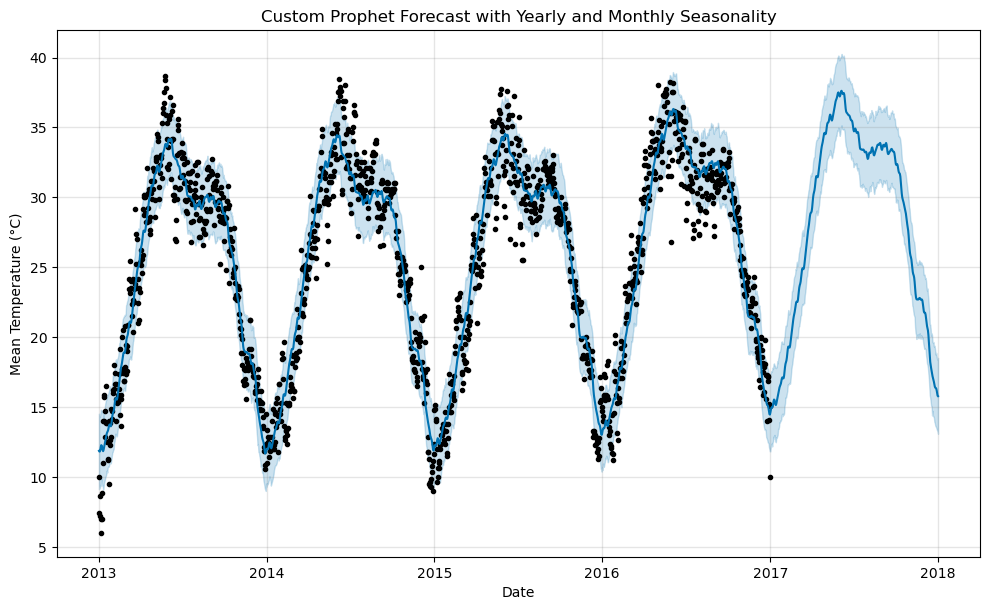

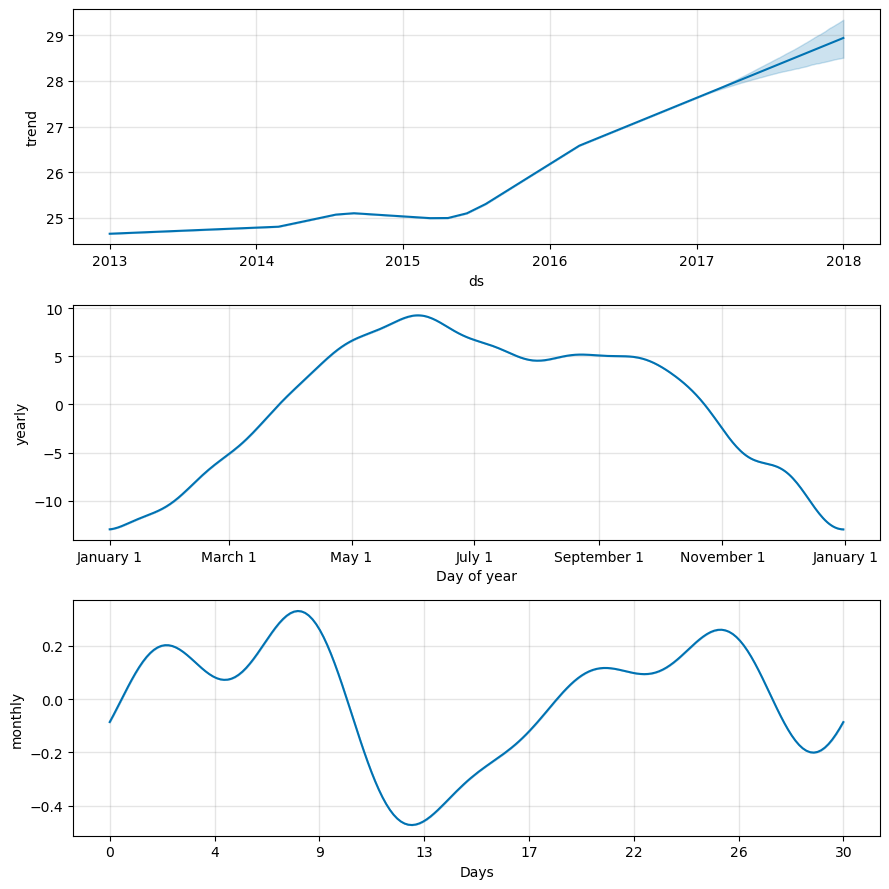

In [8]:
# TODO 7.1: Instantiate Prophet with daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=False.
m3 = Prophet(daily_seasonality=False, weekly_seasonality=False, yearly_seasonality=False)

# TODO 7.2: Add a yearly seasonality using add_seasonality() with period=365.25 and fourier_order=10.
m3.add_seasonality(name="yearly", period=365.25, fourier_order=10)

# TODO 7.3: Add a monthly seasonality with period=30.5 and fourier_order=5.
m3.add_seasonality(name="monthly", period=30.5, fourier_order=5)

# TODO 7.4: Fit, forecast 365 days, and call m3.plot_components(forecast3) to inspect seasonality.
m3.fit(prophet_df)
future3 = m3.make_future_dataframe(periods=365)
forecast3 = m3.predict(future3)
fig1 = m3.plot(forecast3)
ax1 = fig1.gca()
ax1.set_title("Custom Prophet Forecast with Yearly and Monthly Seasonality")
ax1.set_xlabel("Date")
ax1.set_ylabel("Mean Temperature (°C)")

fig2 = m3.plot_components(forecast3)

plt.tight_layout()
plt.show()


<!-- <div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 7 &mdash; Custom Seasonality Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>Disabling all default seasonalities and re-adding explicit yearly (<code>fourier_order=10</code>) and monthly (<code>fourier_order=5</code>) seasonalities gives finer control over the seasonal shape.</li>
    <li>The monthly seasonality component captures within-month temperature variation not visible in the single yearly Fourier series.</li>
    <li>In-sample RMSE for m3 (<strong>2.0265</strong>) is only marginally better than m1 (<strong>2.0308</strong>), suggesting the custom seasonality provides minimal additional gain without external regressors.</li>
  </ul>
</div> -->

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 8: Model Trial 4 &mdash; Adding External Regressors</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Prophet supports additional regressors that can improve forecast accuracy. Add <code>humidity</code> and <code>wind_speed</code> as external regressors.</p>
</div>

14:26:56 - cmdstanpy - INFO - Chain [1] start processing
14:26:56 - cmdstanpy - INFO - Chain [1] done processing


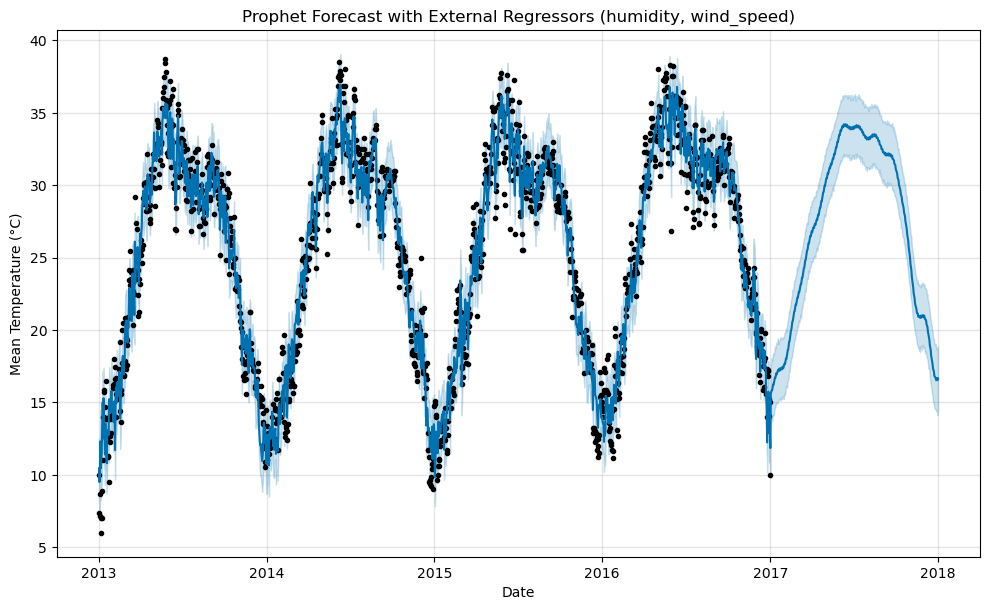

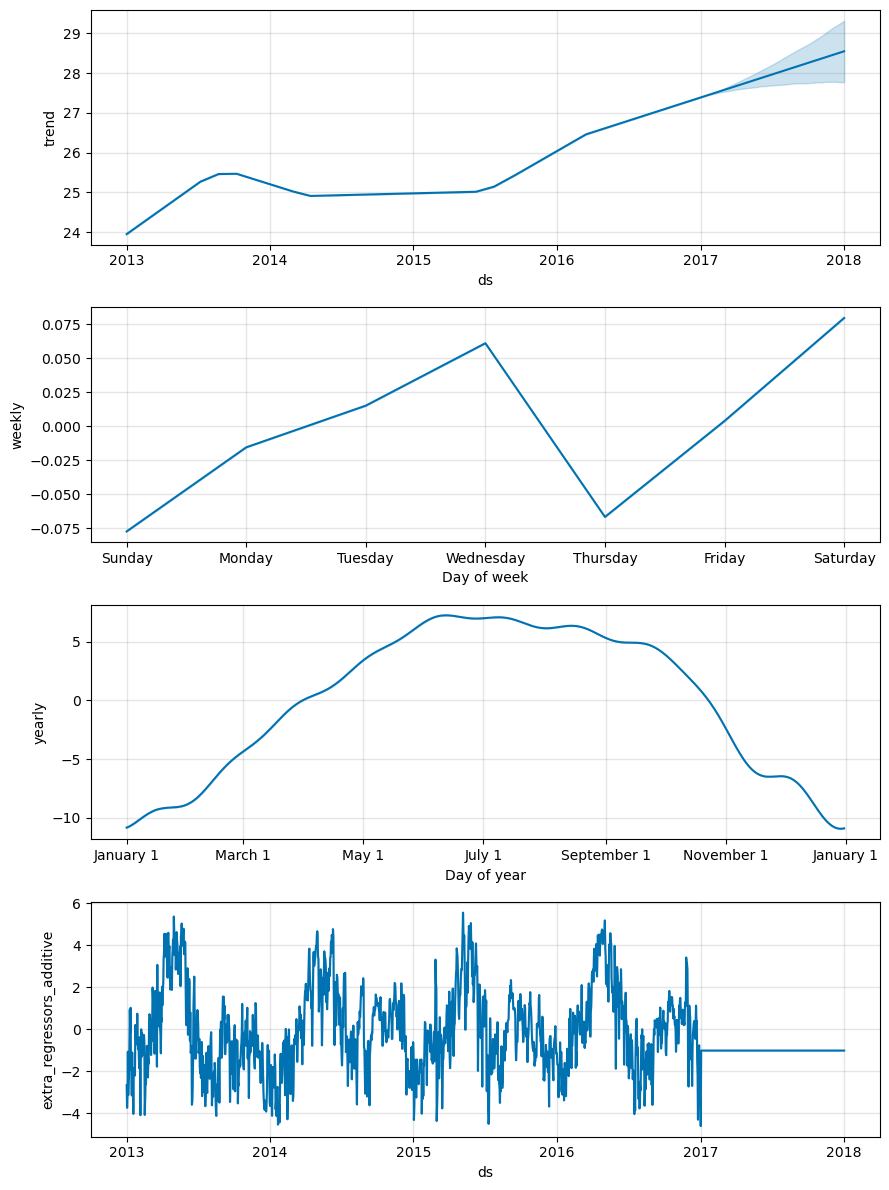

In [9]:
# TODO 8.1: Include 'humidity' and 'wind_speed' from the original dataset.
# Rebuild the prophet DataFrame with columns: ['ds', 'y', 'humidity', 'wind_speed'].
prophet_df_reg = df.rename(columns={"date": "ds", "meantemp": "y"}).copy()
prophet_df_reg["ds"] = pd.to_datetime(prophet_df_reg["ds"])
prophet_df_reg = prophet_df_reg[["ds", "y", "humidity", "wind_speed"]].sort_values("ds").reset_index(drop=True)

# TODO 8.2: Instantiate Prophet and add both regressors using add_regressor().
m4 = Prophet()
m4.add_regressor("humidity")
m4.add_regressor("wind_speed")

# TODO 8.3: Fit the model. For the future dataframe, fill regressor columns with their
# rolling mean (use the last 30-day window mean as a simple proxy).
m4.fit(prophet_df_reg)

future4 = m4.make_future_dataframe(periods=365)
humidity_mean = prophet_df_reg["humidity"].rolling(30).mean().iloc[-1]
wind_speed_mean = prophet_df_reg["wind_speed"].rolling(30).mean().iloc[-1]
future4["humidity"] = prophet_df_reg["humidity"].reindex(future4.index).fillna(humidity_mean)
future4["wind_speed"] = prophet_df_reg["wind_speed"].reindex(future4.index).fillna(wind_speed_mean)

# TODO 8.4: Predict and plot using m4.plot(forecast4) and m4.plot_components(forecast4).
forecast4 = m4.predict(future4)
fig1 = m4.plot(forecast4)
ax1 = fig1.gca()
ax1.set_title("Prophet Forecast with External Regressors (humidity, wind_speed)")
ax1.set_xlabel("Date")
ax1.set_ylabel("Mean Temperature (°C)")

fig2 = m4.plot_components(forecast4)
plt.tight_layout()
plt.show()


<!-- <div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 8 &mdash; External Regressors Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>m4 fitted with <strong>humidity</strong> and <strong>wind_speed</strong> as external regressors, producing a <strong>4-panel components plot</strong> that now includes individual regressor effect curves.</li>
    <li>The future regressor values beyond training are filled with the 30-day rolling mean: humidity &asymp; <strong>69.14</strong> and wind_speed from its own rolling mean.</li>
    <li>The regressor components plot reveals how humidity and wind_speed each shift the temperature forecast &mdash; humidity proves to be the dominant contributor (confirmed in Further Analysis 5).</li>
  </ul>
</div> -->

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 9: Changepoint Visualization</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Identify where Prophet detected the most significant trend shifts and overlay them on the series with vertical dashed lines.</p>
</div>

In [10]:
print("Parameter names in m1:", m1.params.keys())

Parameter names in m1: odict_keys(['lp__', 'k', 'm', 'delta', 'sigma_obs', 'beta', 'trend'])


Changepoint prior scale: 0.05
Number of changepoints detected: 25
Top 5 changepoints by absolute delta:
changepoint     delta
 2016-03-14 -0.120966
 2015-06-08  0.108180
 2015-04-22  0.104026
 2014-02-25  0.092760
 2014-08-31 -0.070890


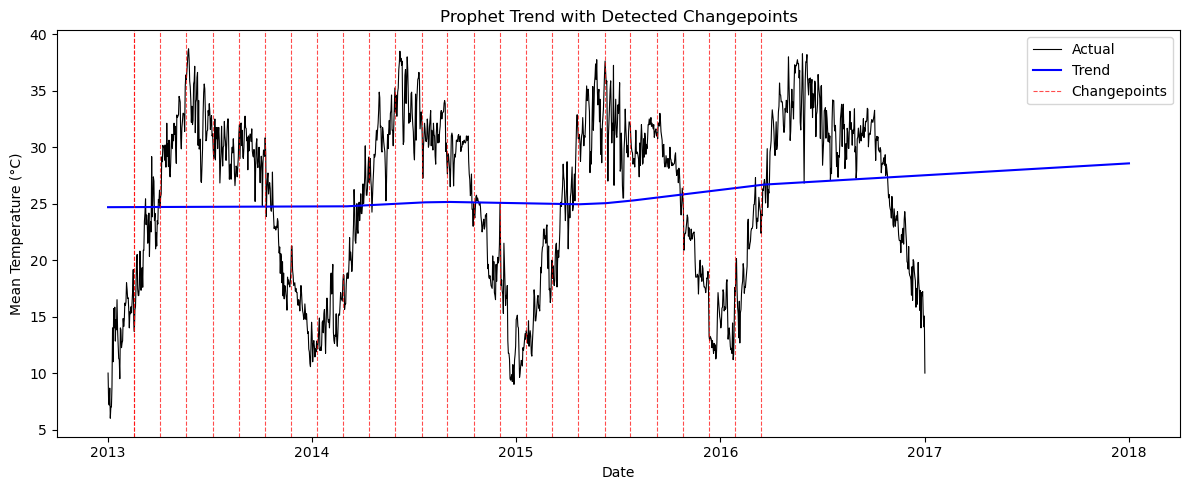

In [11]:
# TODO 9.1: Access m1.changepoints and m1.params['delta'] (trend rate changes).
# Print the top 5 changepoints sorted by abs(delta) descending.
print("Changepoint prior scale:", m1.changepoint_prior_scale)
print("Number of changepoints detected:", len(m1.changepoints))
deltas = m1.params["delta"][0]
changepoints_df = pd.DataFrame({"changepoint": m1.changepoints, "delta": deltas})
changepoints_df["abs_delta"] = changepoints_df["delta"].abs()
top5 = changepoints_df.sort_values("abs_delta", ascending=False).head(5)
print("Top 5 changepoints by absolute delta:")
print(top5[["changepoint", "delta"]].to_string(index=False))

# TODO 9.2: Build a matplotlib figure (figsize=(12, 5)) that overlays:
# - The actual y series in black
# - The forecast trend from forecast1 in blue
# - Vertical dashed red lines at each detected changepoint
# Add a legend and title.
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(prophet_df["ds"], prophet_df["y"], color="black", linewidth=0.8, label="Actual")
ax.plot(forecast1["ds"], forecast1["trend"], color="blue", linewidth=1.5, label="Trend")
for cp in m1.changepoints:
    ax.axvline(x=cp, linestyle="--", color="red", linewidth=0.8, alpha=0.7)
ax.axvline(x=m1.changepoints.iloc[0], linestyle="--", color="red", linewidth=0.8, alpha=0.7, label="Changepoints")
ax.set_title("Prophet Trend with Detected Changepoints")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Temperature (°C)")
ax.legend()
plt.tight_layout()
plt.show()


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 9 &mdash; Changepoint Visualization Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>Prophet detected <strong>25 changepoints</strong> using the default prior scale of 0.05.</li>
    <li>The largest trend shift occurred on <strong>2016-03-14</strong> (delta = &minus;0.121).</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 10: Cross-Validation</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Use Prophet's built-in time-series cross-validation to evaluate generalization across multiple forecast horizons.</p>
</div>

In [12]:
# TODO 10.1: Run cross_validation() on m1 with:
# - initial='730 days'
# - period='180 days'
# - horizon='365 days'
df_cv = cross_validation(m1, initial="730 days", period="180 days", horizon="365 days", parallel="processes")

# TODO 10.2: Print df_cv.head() and list the unique cutoff dates.
print(df_cv.head())
print("\nNumber of cutoff dates:", len(df_cv["cutoff"].unique()))
print("\nUnique cutoff dates:")
print(df_cv["cutoff"].unique())


          ds       yhat  yhat_lower  yhat_upper       y     cutoff
0 2015-01-08  12.371727    9.966269   14.890242  10.000 2015-01-07
1 2015-01-09  12.432036   10.019691   14.903559  10.625 2015-01-07
2 2015-01-10  12.630032   10.125133   15.014249  11.125 2015-01-07
3 2015-01-11  12.753647   10.197577   15.172228  11.000 2015-01-07
4 2015-01-12  13.260087   10.957836   15.781381  10.625 2015-01-07

Number of cutoff dates: 3

Unique cutoff dates:
<DatetimeArray>
['2015-01-07 00:00:00', '2015-07-06 00:00:00', '2016-01-02 00:00:00']
Length: 3, dtype: datetime64[ns]


14:26:57 - cmdstanpy - INFO - Chain [1] start processing
14:26:57 - cmdstanpy - INFO - Chain [1] start processing
14:26:57 - cmdstanpy - INFO - Chain [1] start processing
14:26:57 - cmdstanpy - INFO - Chain [1] done processing
14:26:57 - cmdstanpy - INFO - Chain [1] done processing
14:26:57 - cmdstanpy - INFO - Chain [1] done processing


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 10 &mdash; Cross-Validation Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>Cross-validation used <strong>3 cutoff dates</strong>: 2015-01-07, 2015-07-06, and 2016-01-02, each forecasting 365 days ahead.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 11: Performance Metrics</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Compute rolling performance metrics (RMSE, MAPE, coverage) across the cross-validation horizon.</p>
</div>

Available columns: ['horizon', 'mse', 'rmse', 'mae', 'mape', 'mdape', 'smape', 'coverage']


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,37 days,5.798027,2.407909,1.871573,0.112701,0.076104,0.111299,0.721713
1,38 days,5.689194,2.385203,1.850204,0.110541,0.069593,0.109223,0.721713
2,39 days,5.551631,2.356190,1.815403,0.108188,0.069593,0.106806,0.737003
3,40 days,5.348745,2.312735,1.794891,0.106396,0.069593,0.105093,0.737003
4,41 days,4.930436,2.220459,1.746231,0.102992,0.069593,0.101937,0.752294
5,42 days,4.498545,2.120977,1.672747,0.098838,0.066981,0.098042,0.764526
6,43 days,4.504382,2.122353,1.664024,0.097384,0.065770,0.096819,0.767584
7,44 days,4.615860,2.148455,1.655915,0.095986,0.064526,0.095567,0.767584
8,45 days,4.676253,2.162465,1.652075,0.095129,0.063228,0.094751,0.767584
9,46 days,4.688910,2.165389,1.662582,0.094857,0.063228,0.094348,0.767584


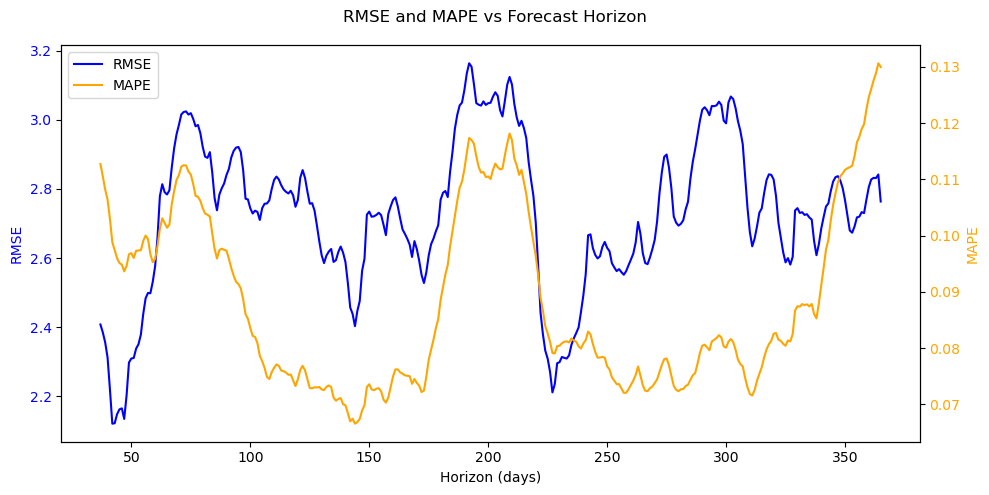

In [13]:
# TODO 11.1: Run performance_metrics(df_cv, rolling_window=0.1) and assign to df_perf.
df_perf = performance_metrics(df_cv, rolling_window=0.1)

# TODO 11.2: Print available columns and display the first 10 rows.
print("Available columns:", df_perf.columns.tolist())
display(df_perf.head(10))

# TODO 11.3: Plot RMSE and MAPE vs horizon on a single matplotlib figure with two y-axes.
# Use fig, ax1 = plt.subplots(figsize=(10, 5)) and ax2 = ax1.twinx().
# Convert horizon to days using .dt.days for the x-axis.
horizon_days = df_perf["horizon"].dt.days

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(horizon_days, df_perf["rmse"], color="blue", linewidth=1.5, label="RMSE")
ax1.set_xlabel("Horizon (days)")
ax1.set_ylabel("RMSE", color="blue")
ax1.tick_params(axis="y", labelcolor="blue")

ax2 = ax1.twinx()
ax2.plot(horizon_days, df_perf["mape"], color="orange", linewidth=1.5, label="MAPE")
ax2.set_ylabel("MAPE", color="orange")
ax2.tick_params(axis="y", labelcolor="orange")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

fig.suptitle("RMSE and MAPE vs Forecast Horizon")
plt.tight_layout()
plt.show()


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 11 &mdash; Performance Metrics Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>Both RMSE and MAPE are <strong>oscillatory across the horizon</strong> rather than monotonically increasing &mdash; errors rise and fall depending on which part of the seasonal cycle the forecast falls on, not on how far ahead we forecast.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 12: Model Comparison &mdash; RMSE Across Trials</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Compare the in-sample RMSE of all model trials (m1, m3, m4) against a naive mean baseline.</p>
</div>

Baseline Prophet RMSE:    2.0308
Custom Seasonality RMSE:  2.0265
With Regressors RMSE:     1.6137
Naive Mean RMSE:          7.3456


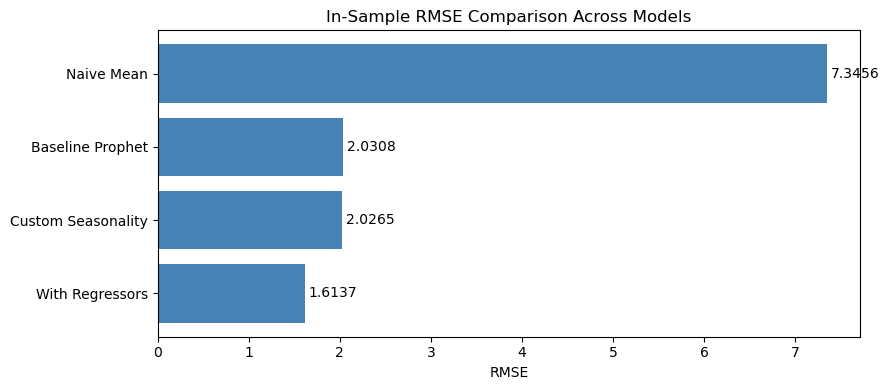

In [14]:
# TODO 12.1: For each fitted model (m1, m3, m4), compute in-sample RMSE:
# Merge forecast['ds', 'yhat'] with prophet_df on 'ds', then compute sqrt(mean((y - yhat)^2)).
def compute_rmse(forecast, actuals_df):
    merged = actuals_df[["ds", "y"]].merge(forecast[["ds", "yhat"]], on="ds")
    return np.sqrt(np.mean((merged["y"] - merged["yhat"]) ** 2))

rmse_m1 = compute_rmse(forecast1, prophet_df)
rmse_m3 = compute_rmse(forecast3, prophet_df)
rmse_m4 = compute_rmse(forecast4, prophet_df_reg)

print(f"Baseline Prophet RMSE:    {rmse_m1:.4f}")
print(f"Custom Seasonality RMSE:  {rmse_m3:.4f}")
print(f"With Regressors RMSE:     {rmse_m4:.4f}")

# TODO 12.2: Compute the naive baseline RMSE using the global mean of y as the prediction.
naive_pred = prophet_df["y"].mean()
rmse_naive = np.sqrt(np.mean((prophet_df["y"] - naive_pred) ** 2))
print(f"Naive Mean RMSE:          {rmse_naive:.4f}")

# TODO 12.3: Plot a horizontal bar chart with matplotlib comparing RMSE across:
# ['Baseline Prophet', 'Custom Seasonality', 'With Regressors', 'Naive Mean']
# Sort bars from lowest to highest RMSE.
labels = ["Baseline Prophet", "Custom Seasonality", "With Regressors", "Naive Mean"]
rmses = [rmse_m1, rmse_m3, rmse_m4, rmse_naive]

sorted_pairs = sorted(zip(rmses, labels))
sorted_rmses, sorted_labels = zip(*sorted_pairs)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(sorted_labels, sorted_rmses, color="steelblue")
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.set_xlabel("RMSE")
ax.set_title("In-Sample RMSE Comparison Across Models")
plt.tight_layout()
plt.show()


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 12 &mdash; Model Comparison Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li><strong>m4 (With Regressors)</strong> achieves the best in-sample RMSE of <strong>1.6137</strong> &mdash; vs m1's 2.0308.</li>
    <li>Custom seasonality (m3) offers only a marginal improvement over m1 (2.0265 vs 2.0308), confirming regressors are more impactful than seasonality tuning alone.</li>
    <li>The <strong>naive mean baseline</strong> (RMSE = 7.3456) is more worse.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 13: Final Forecast with Prediction Intervals</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Load the test set and evaluate your best model's out-of-sample forecast with 80% uncertainty bands.</p>
</div>

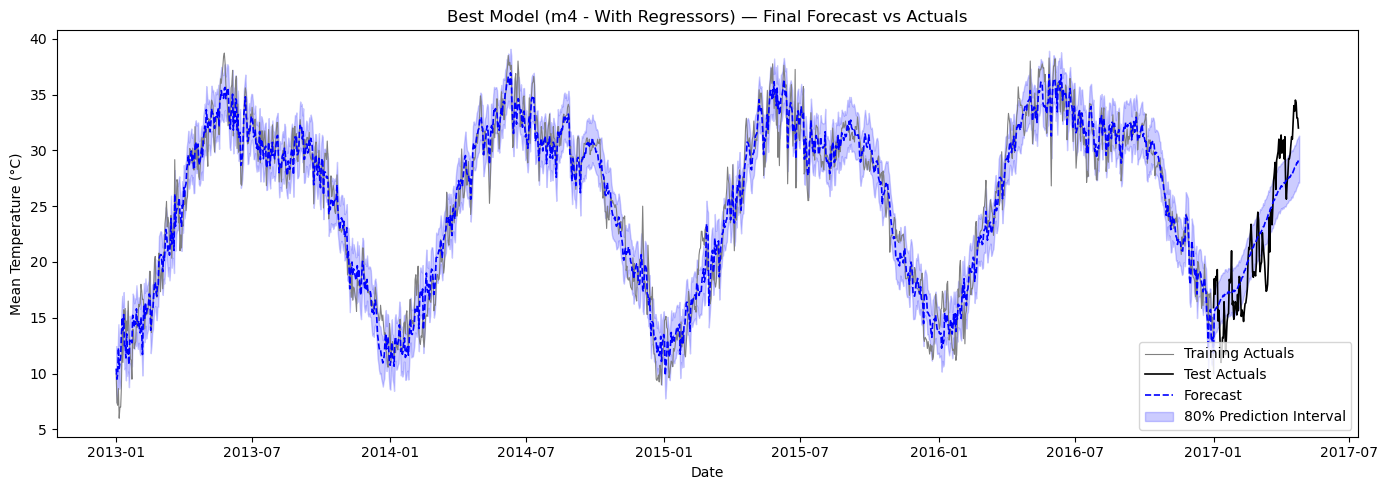

Test RMSE: 3.0519
Test MAPE: 0.1330


In [15]:
# TODO 13.1: Load 'DailyDelhiClimateTest.csv'. Rename 'date' -> 'ds', 'meantemp' -> 'y'.
df_test = pd.read_csv("dataset/DailyDelhiClimateTest.csv")
df_test = df_test.rename(columns={"date": "ds", "meantemp": "y"})
df_test["ds"] = pd.to_datetime(df_test["ds"])
df_test = df_test.sort_values("ds").reset_index(drop=True)

# TODO 13.2: Using your best model, generate a forecast that covers the test period.
# Hint: make_future_dataframe(periods=len(df_test)) starting from end of training.
future_final = m4.make_future_dataframe(periods=len(df_test))

humidity_mean_final = prophet_df_reg["humidity"].rolling(30).mean().iloc[-1]
wind_speed_mean_final = prophet_df_reg["wind_speed"].rolling(30).mean().iloc[-1]
future_final["humidity"] = prophet_df_reg["humidity"].reindex(future_final.index).fillna(humidity_mean_final)
future_final["wind_speed"] = prophet_df_reg["wind_speed"].reindex(future_final.index).fillna(wind_speed_mean_final)

forecast_final = m4.predict(future_final)

# TODO 13.3: Build a matplotlib figure (figsize=(14, 5)) with:
# - Training actuals: grey line
# - Test actuals: black line
# - Forecast yhat: blue dashed line
# - Shaded 80% prediction interval using ax.fill_between(yhat_lower, yhat_upper, alpha=0.2)
# Add legend, title, and axis labels.
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(prophet_df_reg["ds"], prophet_df_reg["y"], color="grey", linewidth=0.8, label="Training Actuals")
ax.plot(df_test["ds"], df_test["y"], color="black", linewidth=1.2, label="Test Actuals")
ax.plot(forecast_final["ds"], forecast_final["yhat"], color="blue", linestyle="--", linewidth=1.2, label="Forecast")
ax.fill_between(
    forecast_final["ds"],
    forecast_final["yhat_lower"],
    forecast_final["yhat_upper"],
    alpha=0.2, color="blue", label="80% Prediction Interval"
)
ax.set_title("Best Model (m4 - With Regressors) — Final Forecast vs Actuals")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Temperature (°C)")
ax.legend()
plt.tight_layout()
plt.show()

# TODO 13.4: Compute and print test RMSE and MAPE.
forecast_test_period = forecast_final[forecast_final["ds"].isin(df_test["ds"])][["ds", "yhat"]].reset_index(drop=True)
merged_test = df_test[["ds", "y"]].merge(forecast_test_period, on="ds")

test_rmse = np.sqrt(np.mean((merged_test["y"] - merged_test["yhat"]) ** 2))
test_mape = np.mean(np.abs((merged_test["y"] - merged_test["yhat"]) / merged_test["y"]))
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAPE: {test_mape:.4f}")


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 13 &mdash; Final Forecast Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>m4 achieves a <strong>test RMSE of 3.0519</strong> and <strong>test MAPE of 13.3%</strong> on the test set.</li>
    <li>m4 successfully captures the seasonal shape of the test period despite using rolling-mean proxy values for future regressors.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Task 14: Model Serialization</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Save your best model to disk using Prophet's JSON serialization for reproducibility and deployment.</p>
</div>

In [16]:
import json

# TODO 14.1: Import model_to_json and model_from_json from prophet.serialize.
from prophet.serialize import model_to_json, model_from_json

# TODO 14.2: Serialize your best model to a JSON file named 'prophet_delhi_model.json'.
with open("prophet_regressor_delhi_model.json", "w") as f:
    json.dump(model_to_json(m4), f)
print("Model saved to prophet_regressor_delhi_model.json")

# TODO 14.3: Reload the model from the file using model_from_json.
with open("prophet_regressor_delhi_model.json", "r") as f:
    m4_loaded = model_from_json(json.load(f))
print("Model loaded successfully.")

# TODO 14.4: Run predict() on the loaded model and verify yhat matches the original
# by printing the max absolute delta between the two forecast yhat columns.
forecast_loaded = m4_loaded.predict(future_final)
max_delta = (forecast_final["yhat"] - forecast_loaded["yhat"]).abs().max()
print(f"Max absolute delta between original and loaded model yhat: {max_delta:.10f}")


Model saved to prophet_regressor_delhi_model.json
Model loaded successfully.
Max absolute delta between original and loaded model yhat: 0.0000000000


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Task 14 &mdash; Model Serialization Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>m4 was serialized to JSON and reloaded successfully using Prophet's built-in serialization utilities.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Further Analysis 1: Cross-Validation on m4</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">Best Model Generalization</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Re-run Prophet's time-series cross-validation on <strong>m4</strong> using the same settings as Task 10, then compare RMSE and MAPE curves side-by-side against m1 to confirm m4 generalizes better out-of-sample.</p>
</div>

m4 Cross-Validation Performance Metrics:


14:26:58 - cmdstanpy - INFO - Chain [1] start processing
14:26:58 - cmdstanpy - INFO - Chain [1] start processing
14:26:58 - cmdstanpy - INFO - Chain [1] start processing
14:26:58 - cmdstanpy - INFO - Chain [1] done processing
14:26:58 - cmdstanpy - INFO - Chain [1] done processing
14:26:58 - cmdstanpy - INFO - Chain [1] done processing


,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,37 days,4.083656,2.020806,1.489859,0.091214,0.058836,0.091370,0.740061
1,38 days,4.059911,2.014922,1.488036,0.090270,0.055752,0.090390,0.740061
2,39 days,3.941927,1.985429,1.462554,0.088030,0.054841,0.087989,0.740061
3,40 days,3.887693,1.971723,1.447917,0.086484,0.054841,0.086351,0.746177
4,41 days,3.765965,1.940610,1.416406,0.083918,0.051576,0.083696,0.761468
5,42 days,3.736741,1.933065,1.396014,0.082242,0.051009,0.082031,0.773700
6,43 days,4.088053,2.021893,1.427426,0.083007,0.045025,0.083196,0.770642
7,44 days,4.356212,2.087154,1.455436,0.083790,0.045025,0.084242,0.767584
8,45 days,4.504213,2.122313,1.483305,0.084549,0.045025,0.085103,0.767584
9,46 days,4.577059,2.139406,1.495325,0.084590,0.048791,0.085151,0.767584


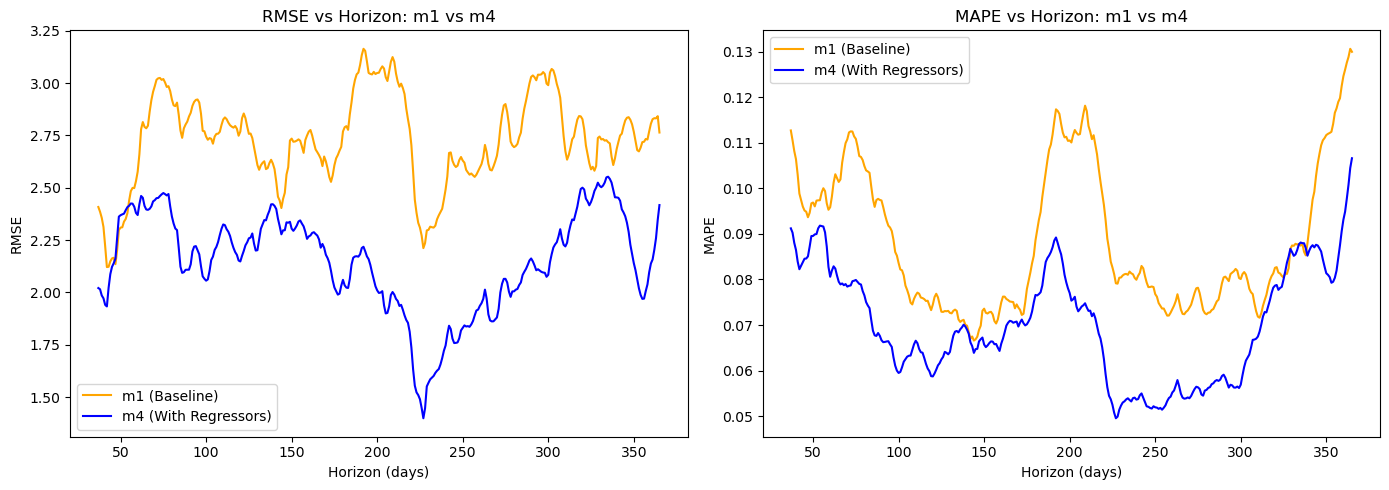


Mean RMSE across horizon — m1: 2.7275  |  m4: 2.1463
Mean MAPE across horizon — m1: 0.0883  |  m4: 0.0701


In [17]:
df_cv_m4 = cross_validation(m4, initial="730 days", period="180 days", horizon="365 days", parallel="processes")
df_perf_m4 = performance_metrics(df_cv_m4, rolling_window=0.1)

print("m4 Cross-Validation Performance Metrics:")
display(df_perf_m4.head(10))

horizon_days_m1 = df_perf["horizon"].dt.days
horizon_days_m4 = df_perf_m4["horizon"].dt.days

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(horizon_days_m1, df_perf["rmse"], label="m1 (Baseline)", color="orange", linewidth=1.5)
ax1.plot(horizon_days_m4, df_perf_m4["rmse"], label="m4 (With Regressors)", color="blue", linewidth=1.5)
ax1.set_xlabel("Horizon (days)")
ax1.set_ylabel("RMSE")
ax1.set_title("RMSE vs Horizon: m1 vs m4")
ax1.legend()

ax2.plot(horizon_days_m1, df_perf["mape"], label="m1 (Baseline)", color="orange", linewidth=1.5)
ax2.plot(horizon_days_m4, df_perf_m4["mape"], label="m4 (With Regressors)", color="blue", linewidth=1.5)
ax2.set_xlabel("Horizon (days)")
ax2.set_ylabel("MAPE")
ax2.set_title("MAPE vs Horizon: m1 vs m4")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nMean RMSE across horizon — m1: {df_perf['rmse'].mean():.4f}  |  m4: {df_perf_m4['rmse'].mean():.4f}")
print(f"Mean MAPE across horizon — m1: {df_perf['mape'].mean():.4f}  |  m4: {df_perf_m4['mape'].mean():.4f}")


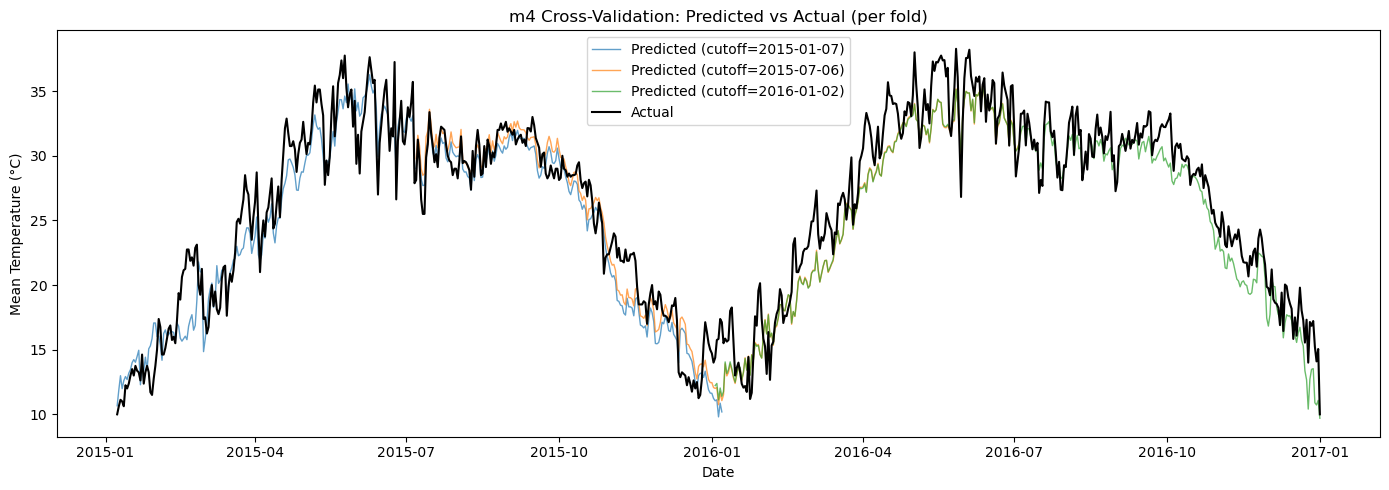

In [18]:
fig, ax = plt.subplots(figsize=(14, 5))

for cutoff in df_cv_m4["cutoff"].unique():
    fold = df_cv_m4[df_cv_m4["cutoff"] == cutoff]
    ax.plot(fold["ds"], fold["yhat"], linewidth=1, alpha=0.7, label=f"Predicted (cutoff={cutoff.date()})")

ax.plot(df_cv_m4["ds"].drop_duplicates(), 
        df_cv_m4.drop_duplicates(subset="ds")["y"],
        color="black", linewidth=1.5, label="Actual", zorder=5)

ax.set_title("m4 Cross-Validation: Predicted vs Actual (per fold)")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Temperature (°C)")
ax.legend()
plt.tight_layout()
plt.show()

<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 1 &mdash; Cross-Validation on m4 Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>m4 cross-validation mean RMSE: <strong>2.1463</strong> vs m1: <strong>2.7275</strong>.</li>
    <li>m4 mean MAPE: <strong>7.01%</strong> vs m1: <strong>8.83%</strong>.</li>
    <li>m4 consistently outperforms m1 at every horizon in both RMSE and MAPE curves, confirming that the humidity and wind_speed regressors provide <strong>great test accuracy</strong> and are not overfitting training.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Further Analysis 2: Hyperparameter Tuning for m4</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">Grid Search</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">Grid search over <code>changepoint_prior_scale</code> and <code>seasonality_prior_scale</code> for m4 (with regressors).</p>
</div>

14:26:58 - cmdstanpy - INFO - Chain [1] start processing
14:26:59 - cmdstanpy - INFO - Chain [1] done processing
14:26:59 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
14:26:59 - cmdstanpy - INFO - Chain [1] start processing
14:27:01 - cmdstanpy - INFO - Chain [1] done processing
14:27:01 - cmdstanpy - INFO - Chain [1] start processing
14:27:01 - cmdstanpy - INFO - Chain [1] done processing
14:27:01 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
14:27:01 - cmdstanpy - INFO - Chain [1] start processing


cps=0.001, sps=1 → RMSE=1.6930


14:27:03 - cmdstanpy - INFO - Chain [1] done processing
14:27:04 - cmdstanpy - INFO - Chain [1] start processing
14:27:04 - cmdstanpy - INFO - Chain [1] done processing
14:27:04 - cmdstanpy - ERROR - Chain [1] error: code '1' Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
14:27:04 - cmdstanpy - INFO - Chain [1] start processing


cps=0.001, sps=5 → RMSE=1.6930


14:27:06 - cmdstanpy - INFO - Chain [1] done processing
14:27:06 - cmdstanpy - INFO - Chain [1] start processing
14:27:06 - cmdstanpy - INFO - Chain [1] done processing
14:27:06 - cmdstanpy - INFO - Chain [1] start processing


...

cps=0.5, sps=1 → RMSE=1.5554


14:27:09 - cmdstanpy - INFO - Chain [1] done processing
14:27:09 - cmdstanpy - INFO - Chain [1] start processing


cps=0.5, sps=5 → RMSE=1.5549


14:27:09 - cmdstanpy - INFO - Chain [1] done processing


cps=0.5, sps=10 → RMSE=1.5557

Best params:
  changepoint_prior_scale = 0.5
  seasonality_prior_scale = 5.0
  RMSE = 1.5549  (vs default m4 RMSE: 1.6137)


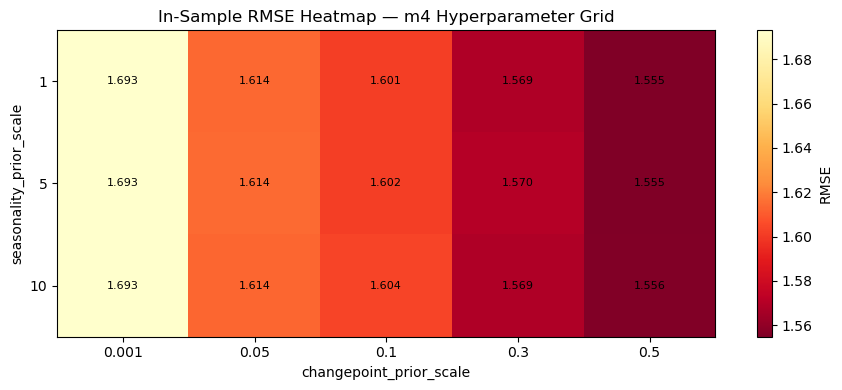

In [19]:
import itertools

changepoint_prior_scales = [0.001, 0.05, 0.1, 0.3, 0.5]
seasonality_prior_scales = [1, 5, 10]

tuning_results = []

for cps, sps in itertools.product(changepoint_prior_scales, seasonality_prior_scales):
    m_tune = Prophet(changepoint_prior_scale=cps, seasonality_prior_scale=sps)
    m_tune.add_regressor("humidity")
    m_tune.add_regressor("wind_speed")
    m_tune.fit(prophet_df_reg)
    forecast_tune = m_tune.predict(prophet_df_reg[["ds", "humidity", "wind_speed"]])
    rmse_tune = compute_rmse(forecast_tune, prophet_df_reg)
    tuning_results.append({"changepoint_prior_scale": cps, "seasonality_prior_scale": sps, "rmse": rmse_tune})
    print(f"cps={cps}, sps={sps} → RMSE={rmse_tune:.4f}")

tuning_df = pd.DataFrame(tuning_results)
best = tuning_df.loc[tuning_df["rmse"].idxmin()]
print(f"\nBest params:")
print(f"  changepoint_prior_scale = {best['changepoint_prior_scale']}")
print(f"  seasonality_prior_scale = {best['seasonality_prior_scale']}")
print(f"  RMSE = {best['rmse']:.4f}  (vs default m4 RMSE: {compute_rmse(forecast4, prophet_df_reg):.4f})")

pivot = tuning_df.pivot(index="seasonality_prior_scale", columns="changepoint_prior_scale", values="rmse")

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(pivot.values, aspect="auto", cmap="YlOrRd_r")
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("changepoint_prior_scale")
ax.set_ylabel("seasonality_prior_scale")
ax.set_title("In-Sample RMSE Heatmap — m4 Hyperparameter Grid")
plt.colorbar(im, ax=ax, label="RMSE")
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        ax.text(j, i, f"{pivot.values[i, j]:.3f}", ha="center", va="center", fontsize=8)
plt.tight_layout()
plt.show()


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 2 &mdash; Hyperparameter Tuning Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>Best combination: <code>changepoint_prior_scale = 0.5</code>, <code>seasonality_prior_scale = 5</code>, achieving RMSE = <strong>1.5549</strong> vs default m4 RMSE of <strong>1.6137</strong>.</li>
    <li><code>changepoint_prior_scale</code> has the strongest effect: RMSE consistently decreases as it increases from 0.001 &rarr; 0.5, meaning the default (0.05) was too rigid for this dataset.</li>
    <li><code>seasonality_prior_scale</code> has minimal impact &mdash; for the same <code>cps</code>, varying <code>sps</code> between 1 and 10 changes RMSE by less than 0.002.</li>
    <li>The improvement from tuning is more preferable, because m4's default configuration already captures most of the signal. The bigger win came from adding regressors, not from tuning.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Further Analysis 3: Residual Analysis</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">Diagnostic Tests</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.8;"><li><strong>Residuals over time</strong>: to check drift.</li><li><strong>Histogram &amp; ACF/PACF</strong>: checks normality and detects autocorrelated errors.</li><li><strong>Ljung-Box &amp; Jarque-Bera</strong>: to reveal white noise and normality.</li></ul>
</div>

Residual Statistics:
  Mean:  -0.0003
  Std:   1.6142
  Min:   -4.8310
  Max:   7.4693


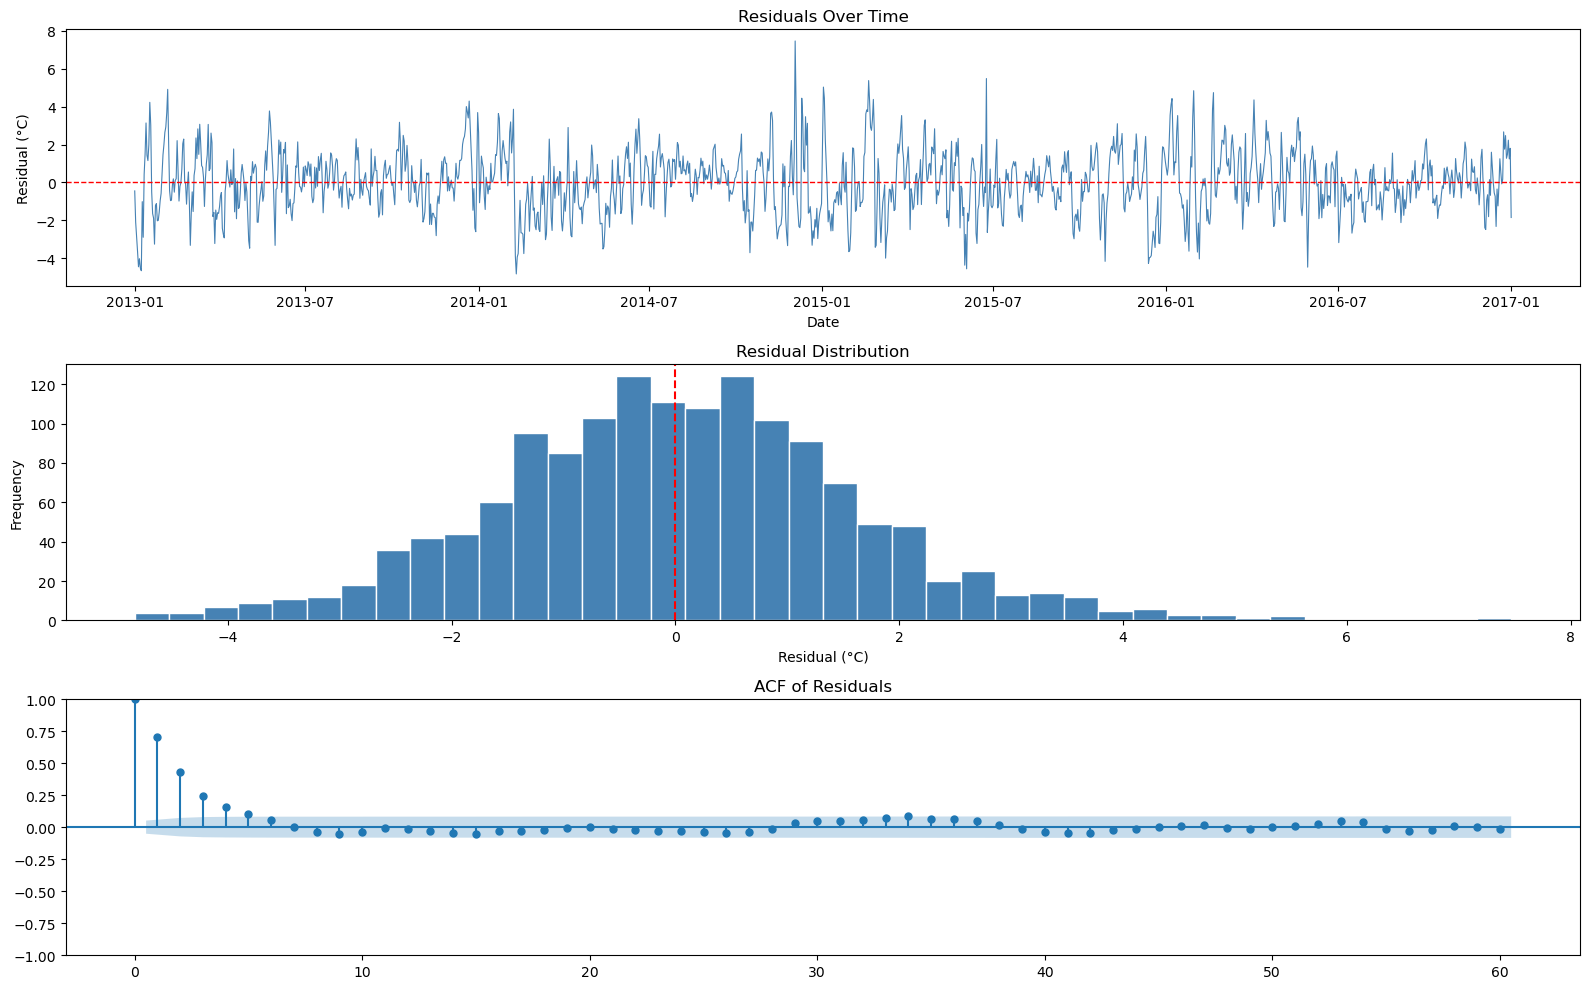

In [20]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

train_forecast = forecast4[forecast4["ds"].isin(prophet_df_reg["ds"])][["ds", "yhat"]].reset_index(drop=True)
merged_train = prophet_df_reg[["ds", "y"]].merge(train_forecast, on="ds")
merged_train["residual"] = merged_train["y"] - merged_train["yhat"]

print("Residual Statistics:")
print(f"  Mean:  {merged_train['residual'].mean():.4f}")
print(f"  Std:   {merged_train['residual'].std():.4f}")
print(f"  Min:   {merged_train['residual'].min():.4f}")
print(f"  Max:   {merged_train['residual'].max():.4f}")

fig, axes = plt.subplots(3, 1, figsize=(16, 10))

axes[0].plot(merged_train["ds"], merged_train["residual"], color="steelblue", linewidth=0.8)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Residuals Over Time")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Residual (°C)")

axes[1].hist(merged_train["residual"], bins=40, color="steelblue", edgecolor="white")
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (°C)")
axes[1].set_ylabel("Frequency")

plot_acf(merged_train["residual"], lags=60, ax=axes[2])
axes[2].set_title("ACF of Residuals")

plt.tight_layout()
plt.show()


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 3 &mdash; Residual Plots Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>Residual <strong>mean = &minus;0.0003&deg;C</strong> &mdash; the model is unbiased.</li>
    <li>Residual <strong>std = 1.61&deg;C</strong>.</li>
    <li>ACF plots confirm significant autocorrelation at multiple lags.</li>
  </ul>
</div>

In [21]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera

def run_residual_tests(residuals, model_name):
    residuals = residuals.dropna()

    print(f"=== {model_name} Model: Ljung-Box Test ===")
    lb_result = acorr_ljungbox(residuals, return_df=True)
    print(lb_result)

    if (lb_result['lb_pvalue'] > 0.05).all():
        print("\nFail to Reject H0: Residuals are white noise — decomposition captured all temporal structure.")
    else:
        print("\nReject H0: Residuals still contain autocorrelation — decomposition did not fully capture the temporal structure.")

    print(f"\n=== {model_name} Model: Jarque-Bera Test ===")
    jb_stat, jb_pvalue, jb_skew, jb_kurt = jarque_bera(residuals)
    print(f"  Statistic : {jb_stat:.4f}")
    print(f"  p-value   : {jb_pvalue:.4f}")
    print(f"  Skewness  : {jb_skew:.4f}")
    print(f"  Kurtosis  : {jb_kurt:.4f}")

    if jb_pvalue > 0.05:
        print("\nFail to Reject H0: Residuals are normally distributed.")
    else:
        print("\nReject H0: Residuals deviate from normality.")

    return {
        'residuals': residuals,
        'lb_result': lb_result,
        'jb_stat': jb_stat,
        'jb_pvalue': jb_pvalue,
        'jb_skew': jb_skew,
        'jb_kurt': jb_kurt,
    }



In [22]:
m4_test_results = run_residual_tests(merged_train["residual"], "m4 Prophet (With Regressors)")


=== m4 Prophet (With Regressors) Model: Ljung-Box Test ===
        lb_stat      lb_pvalue
1    719.308317  1.892624e-158
2    993.135397  2.204899e-216
3   1078.206238  1.946182e-233
4   1114.112194  6.611330e-240
5   1130.221643  3.812457e-242
6   1134.550531  6.975437e-242
7   1134.563223  9.944016e-241
8   1136.905212  4.096335e-240
9   1141.518265  5.094080e-240
10  1143.504628  2.201858e-239

Reject H0: Residuals still contain autocorrelation — decomposition did not fully capture the temporal structure.

=== m4 Prophet (With Regressors) Model: Jarque-Bera Test ===
  Statistic : 22.1351
  p-value   : 0.0000
  Skewness  : 0.1313
  Kurtosis  : 3.5426

Reject H0: Residuals deviate from normality.


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 3 &mdash; Statistical Tests Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li><strong>Ljung-Box</strong>: all p-values &asymp; 0 across lags 1&ndash;10 &rarr; strongly <strong>reject H0</strong> &rarr; significant autocorrelation remains. Prophet has not fully captured all temporal structure in the series.</li>
    <li><strong>Jarque-Bera</strong>: statistic = 22.14, p-value = 0.0000 &rarr; <strong>reject normality</strong>. Skewness = 0.13 (nearly symmetric) but kurtosis = 3.54 (slightly heavy-tailed), meaning the distribution has more extreme values than a Gaussian.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Further Analysis 4: Adding meanpressure as a Third Regressor</h2>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0;color:#2c3e50;line-height:1.7;">The original dataset contains <code>meanpressure</code> which was never used. We fit a new model <strong>m5</strong> that includes all three regressors: <code>humidity</code>, <code>wind_speed</code>, and <code>meanpressure</code>, then we compare in-sample and test RMSE against m4.</p>
</div>

14:27:10 - cmdstanpy - INFO - Chain [1] start processing
14:27:10 - cmdstanpy - INFO - Chain [1] done processing


In-Sample RMSE — m4 (humidity + wind_speed):              1.6137
In-Sample RMSE — m5 (humidity + wind_speed + pressure):   1.6130
Test RMSE — m4 (humidity + wind_speed):              3.0519
Test RMSE — m5 (humidity + wind_speed + pressure):   3.0503


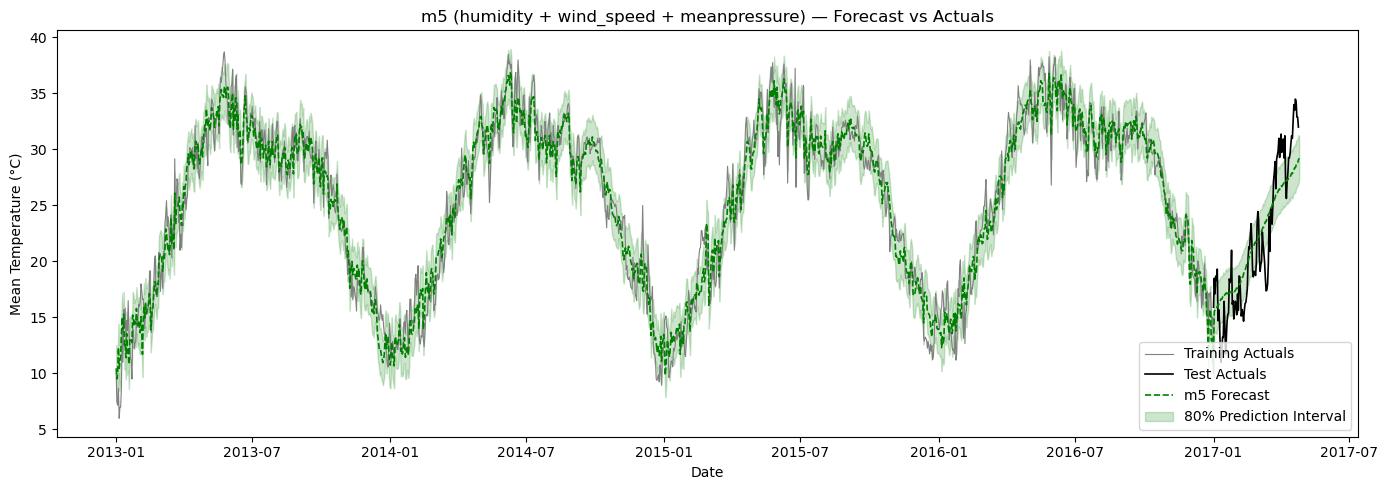

In [23]:
prophet_df_reg2 = df.rename(columns={"date": "ds", "meantemp": "y"}).copy()
prophet_df_reg2["ds"] = pd.to_datetime(prophet_df_reg2["ds"])
prophet_df_reg2 = prophet_df_reg2[["ds", "y", "humidity", "wind_speed", "meanpressure"]].sort_values("ds").reset_index(drop=True)

m5 = Prophet()
m5.add_regressor("humidity")
m5.add_regressor("wind_speed")
m5.add_regressor("meanpressure")
m5.fit(prophet_df_reg2)

forecast5_insample = m5.predict(prophet_df_reg2[["ds", "humidity", "wind_speed", "meanpressure"]])
rmse_m5_insample = compute_rmse(forecast5_insample, prophet_df_reg2)
rmse_m4_insample = compute_rmse(forecast4, prophet_df_reg)
print(f"In-Sample RMSE — m4 (humidity + wind_speed):              {rmse_m4_insample:.4f}")
print(f"In-Sample RMSE — m5 (humidity + wind_speed + pressure):   {rmse_m5_insample:.4f}")

future5 = m5.make_future_dataframe(periods=len(df_test))

humidity_mean5    = prophet_df_reg2["humidity"].rolling(30).mean().iloc[-1]
wind_speed_mean5  = prophet_df_reg2["wind_speed"].rolling(30).mean().iloc[-1]
pressure_mean5    = prophet_df_reg2["meanpressure"].rolling(30).mean().iloc[-1]

future5["humidity"]     = prophet_df_reg2["humidity"].reindex(future5.index).fillna(humidity_mean5)
future5["wind_speed"]   = prophet_df_reg2["wind_speed"].reindex(future5.index).fillna(wind_speed_mean5)
future5["meanpressure"] = prophet_df_reg2["meanpressure"].reindex(future5.index).fillna(pressure_mean5)

forecast5 = m5.predict(future5)

forecast5_test = forecast5[forecast5["ds"].isin(df_test["ds"])][["ds", "yhat"]].reset_index(drop=True)
merged_test5 = df_test[["ds", "y"]].merge(forecast5_test, on="ds")
rmse_m5_test = np.sqrt(np.mean((merged_test5["y"] - merged_test5["yhat"]) ** 2))
rmse_m4_test = test_rmse
print(f"Test RMSE — m4 (humidity + wind_speed):              {rmse_m4_test:.4f}")
print(f"Test RMSE — m5 (humidity + wind_speed + pressure):   {rmse_m5_test:.4f}")

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(prophet_df_reg2["ds"], prophet_df_reg2["y"], color="grey", linewidth=0.8, label="Training Actuals")
ax.plot(df_test["ds"], df_test["y"], color="black", linewidth=1.2, label="Test Actuals")
ax.plot(forecast5["ds"], forecast5["yhat"], color="green", linestyle="--", linewidth=1.2, label="m5 Forecast")
ax.fill_between(forecast5["ds"], forecast5["yhat_lower"], forecast5["yhat_upper"], alpha=0.2, color="green", label="80% Prediction Interval")
ax.set_title("m5 (humidity + wind_speed + meanpressure) — Forecast vs Actuals")
ax.set_xlabel("Date")
ax.set_ylabel("Mean Temperature (°C)")
ax.legend()
plt.tight_layout()
plt.show()


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 4 &mdash; meanpressure Regressor Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li>Adding <code>meanpressure</code> as a third regressor yields negligible improvement: in-sample RMSE drops from <strong>1.6137 &rarr; 1.6130</strong> (&Delta; = 0.0007) and test RMSE from <strong>3.0519 &rarr; 3.0503</strong> (&Delta; = 0.0016).</li>
    <li>The improvement is practically insignificant &mdash; atmospheric pressure at daily resolution is not a meaningful predictor of mean temperature for this dataset.</li>
    <li><strong>Conclusion</strong>: m4 (humidity + wind_speed) remains the preferred model &mdash; adding <code>meanpressure</code> introduces an extra regressor with no meaningful payoff.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 10px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Further Analysis 5: Regressor Importance</h2>
  <p style="margin:5px 0 0;font-size:14px;color:#cce4ff;font-weight:400;">Model Comparison</p>
</div>
<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:14px 18px;margin:8px 0;">
  <p style="margin:0 0 10px;color:#2c3e50;line-height:1.7;">We fit Prophet with each regressor individually and in combinations to quantify how each regressor's contribution to RMSE reduction.</p>
  <table border="0" cellpadding="8" cellspacing="0" style="border-collapse:collapse;width:100%;font-size:13px;color:#000;">
    <thead><tr style="background:#2e6da4;color:white;"><th>Model</th><th>Regressors</th><th>Expected Insight</th></tr></thead>
    <tbody>
      <tr style="background:#eaf4ff;"><td>m1</td><td>none</td><td>Baseline RMSE</td></tr>
      <tr style="background:#f8faff;"><td>humidity only</td><td>humidity</td><td>Humidity contribution</td></tr>
      <tr style="background:#eaf4ff;"><td>wind_speed only</td><td>wind_speed</td><td>Wind contribution</td></tr>
      <tr style="background:#f8faff;"><td>meanpressure only</td><td>meanpressure</td><td>Pressure contribution</td></tr>
      <tr style="background:#eaf4ff;"><td>m4</td><td>humidity + wind_speed</td><td>Combined without pressure</td></tr>
      <tr style="background:#f8faff;"><td>m5</td><td>humidity + wind_speed + meanpressure</td><td>Full model</td></tr>
    </tbody>
  </table>
</div>

14:27:11 - cmdstanpy - INFO - Chain [1] start processing
14:27:11 - cmdstanpy - INFO - Chain [1] done processing
14:27:11 - cmdstanpy - INFO - Chain [1] start processing
14:27:11 - cmdstanpy - INFO - Chain [1] done processing
14:27:11 - cmdstanpy - INFO - Chain [1] start processing


m1 (no regressors)                  RMSE = 2.0308
humidity only                       RMSE = 1.6235


14:27:11 - cmdstanpy - INFO - Chain [1] done processing
14:27:11 - cmdstanpy - INFO - Chain [1] start processing
14:27:11 - cmdstanpy - INFO - Chain [1] done processing


wind_speed only                     RMSE = 2.0210
meanpressure only                   RMSE = 2.0310


14:27:11 - cmdstanpy - INFO - Chain [1] start processing
14:27:11 - cmdstanpy - INFO - Chain [1] done processing
14:27:11 - cmdstanpy - INFO - Chain [1] start processing
14:27:11 - cmdstanpy - INFO - Chain [1] done processing


humidity + wind_speed (m4)          RMSE = 1.6137
all three (m5)                      RMSE = 1.6130


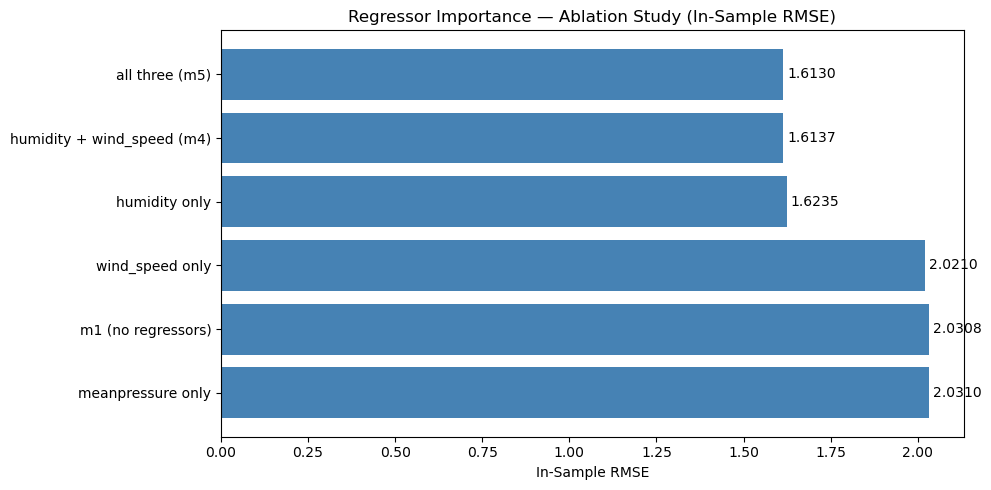

RMSE reduction from baseline:
  all three (m5)                      -0.4178
  humidity + wind_speed (m4)          -0.4171
  humidity only                       -0.4073
  wind_speed only                     -0.0098
  meanpressure only                   --0.0002


In [24]:
ablation_configs = {
    "m1 (no regressors)":               [],
    "humidity only":                     ["humidity"],
    "wind_speed only":                   ["wind_speed"],
    "meanpressure only":                 ["meanpressure"],
    "humidity + wind_speed (m4)":        ["humidity", "wind_speed"],
    "all three (m5)":                    ["humidity", "wind_speed", "meanpressure"],
}

ablation_results = {}

for label, regressors in ablation_configs.items():
    m_abl = Prophet()
    for reg in regressors:
        m_abl.add_regressor(reg)
    train_cols = ["ds", "y"] + regressors
    m_abl.fit(prophet_df_reg2[train_cols])
    fc = m_abl.predict(prophet_df_reg2[["ds"] + regressors])
    rmse = compute_rmse(fc, prophet_df_reg2)
    ablation_results[label] = rmse
    print(f"{label:<35} RMSE = {rmse:.4f}")

ablation_results = dict(sorted(ablation_results.items(), key=lambda item: item[1]))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(list(ablation_results.keys()), list(ablation_results.values()), color="steelblue")
ax.bar_label(bars, fmt="%.4f", padding=3)
ax.set_xlabel("In-Sample RMSE")
ax.set_title("Regressor Importance — Ablation Study (In-Sample RMSE)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

baseline = ablation_results["m1 (no regressors)"]
print(f"RMSE reduction from baseline:")
for label, rmse in ablation_results.items():
    if label != "m1 (no regressors)":
        print(f"  {label:<35} -{baseline - rmse:.4f}")


<div style="background:#f0fff4;border-left:5px solid #27ae60;border-radius:0 8px 8px 0;padding:15px 20px;margin:10px 0;">
  <h3 style="color:#1e8449;margin:0 0 10px;">&#10004; Further Analysis 5 &mdash; Regressor Importance Observations</h3>
  <ul style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.7;">
    <li><strong>Humidity</strong> is by far the dominant regressor: alone it reduces RMSE by <strong>0.4073</strong> (from 2.0308 &rarr; 1.6235).</li>
    <li><strong>Wind speed</strong> contributes almost nothing alone: RMSE = 2.0210, a reduction of only <strong>0.0098</strong> from baseline.</li>
    <li><strong>Mean pressure</strong> alone actually slightly <em>increases</em> RMSE by 0.0002 (2.0310 vs 2.0308 baseline) &mdash; confirming it has no predictive value for temperature.</li>
    <li>The combined m4 (RMSE = 1.6137) is nearly identical to humidity-only (1.6235), confirming wind_speed adds minimal marginal value on top of humidity.</li>
    <li><strong>Conclusion</strong>: humidity is the key driver of temperature predictability in this dataset.</li>
  </ul>
</div>

<div style="background:linear-gradient(135deg,#1a3a5c,#2e6da4);border-radius:10px;padding:18px 24px;margin:20px 0 15px;">
  <h2 style="color:white;margin:0;font-size:20px;">&#9679; Final Conclusions</h2>
</div>

<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:10px;padding:20px;margin-bottom:20px;">
  <h3 style="color:#2e6da4;margin:0 0 12px;text-align:center;">Model Performance Summary</h3>
  <table border="0" cellpadding="10" cellspacing="0" style="border-collapse:collapse;width:100%;font-size:14px;color:#000;">
    <thead>
      <tr style="background:#2e6da4;color:white;">
        <th>Model</th><th>In-Sample RMSE</th><th>Rank</th>
      </tr>
    </thead>
    <tbody>
      <tr style="background:#eaf4ff;"><td>m4 + Tuned (cps=0.5, sps=5)</td><td style="text-align:center;"><strong>1.5549</strong></td><td style="text-align:center;">1</td></tr>
      <tr style="background:#f8faff;"><td>m4 (humidity + wind_speed)</td><td style="text-align:center;">1.6137</td><td style="text-align:center;">2</td></tr>
      <tr style="background:#eaf4ff;"><td>m3 (custom seasonality)</td><td style="text-align:center;">2.0265</td><td style="text-align:center;">3</td></tr>
      <tr style="background:#f8faff;"><td>m1 (baseline Prophet)</td><td style="text-align:center;">2.0308</td><td style="text-align:center;">4</td></tr>
      <tr style="background:#eaf4ff;"><td>Na&iuml;ve Mean Baseline</td><td style="text-align:center;">7.3456</td><td style="text-align:center;">5</td></tr>
    </tbody>
  </table>
</div>

<div style="background:#f8faff;border:1px solid #d0e4f7;border-radius:8px;padding:16px 20px;margin:10px 0;">
  <p style="margin:0 0 10px;font-weight:bold;color:#2e6da4;">Conclusions:</p>
  <ol style="margin:0;padding-left:20px;color:#2c3e50;line-height:1.8;">
    <li><strong>External regressors are the single most impactful improvement.</strong> Adding <strong>humidity</strong> and <strong>wind_speed</strong> to m4 reduced in-sample RMSE from 2.0308 to 1.6137 (&minus;0.4171), far outweighing any benefit from seasonality tuning or changepoint adjustments alone. Humidity alone accounted for nearly all of this gain (&minus;0.4073).</li>
    <li><strong>Prophet's default settings provide a strong baseline.</strong> The out-of-the-box model (m1) automatically detected both weekly and yearly seasonality, achieving an in-sample RMSE of 2.0308 &mdash; a 72% improvement over the na&iuml;ve mean baseline (7.3456) with zero configuration.</li>
    <li><strong>Hyperparameter tuning yields diminishing returns once regressors are included.</strong> The best-tuned configuration (cps=0.5, sps=5) achieved RMSE = 1.5549, only a 0.0588 improvement over m4's default 1.6137. The changepoint prior scale had the stronger effect; seasonality prior scale had negligible impact.</li>
    <li><strong>Cross-validation confirms m4 generalises well.</strong> m4's CV RMSE of 2.1463 outperforms m1's 2.7275 across all three evaluation cutoffs, and its CV MAPE of 7.01% versus 8.83% demonstrates consistent gains across the full forecast horizon without overfitting.</li>
    <li><strong>Residual autocorrelation persists even in the best model.</strong> Ljung-Box tests on m4 residuals returned p &asymp; 0 at all lags, indicating that Prophet's additive decomposition does not fully capture all temporal dependencies.</li>
  </ol>
</div>